# Análise Estatística — TCP vs R-UDP

**PPGCC/UFPI · Redes de Computadores 2026-1**  
**Dados:** 30 repetições × 2 modos (TCP, R-UDP) × 3 cenários (A, B, C) = **180 transferências**  
**Arquivo:** `test_1MB.bin` (1.048.576 bytes)  
**Ambiente:** Docker Ubuntu 22.04 · `tc netem` para emulação de rede degradada

| Cenário | Perda | Atraso |
|---------|-------|--------|
| A | 0% | 10 ms |
| B | 10% | 50 ms |
| C | 20% | 100 ms |

In [1]:
# !pip install plotly -q

import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

# ── Working directory ─────────────────────────────────────────────────────────
# Garante que o cwd é a raiz do repositório independente de onde o kernel iniciou
if not os.path.exists('logs/app/client_transfers.jsonl'):
    os.chdir('..')  # kernel iniciou em notebooks/, sobe um nível
print(f'cwd: {os.getcwd()}')

# ── Caminhos ──────────────────────────────────────────────────────────────────
# Local (raiz do repo): paths funcionam como estão
# Colab: faça upload dos JSONL ou monte o Drive e ajuste os paths
CLI_JSONL = 'logs/app/client_transfers.jsonl'
SRV_JSONL = 'logs/app/server_transfers.jsonl'

# Bateria iniciou em 2026-05-28 14:19 BRT = 17:19 UTC
BATTERY_START = pd.Timestamp('2026-05-28T17:19:00', tz='UTC')

# Paleta consistente em todos os gráficos
COLORS = {'TCP': '#1E88E5', 'RUDP': '#E53935'}
SCENARIO_ORDER = {'scenario': ['A', 'B', 'C']}

cwd: /home/anthonym/codes/redes_doutorado


## 1. Carregamento e filtragem

In [2]:
df_cli = pd.read_json(CLI_JSONL, lines=True)
df_srv = pd.read_json(SRV_JSONL, lines=True)

df_cli['start_time'] = pd.to_datetime(df_cli['start_time'], utc=True)
df_srv['start_time'] = pd.to_datetime(df_srv['start_time'], utc=True)

cli = df_cli[df_cli['start_time'] >= BATTERY_START].reset_index(drop=True).copy()
srv = df_srv[df_srv['start_time'] >= BATTERY_START].reset_index(drop=True).copy()

# throughput em MB/s para exibição
cli['throughput_MBps'] = cli['throughput_bytes_s'] / 1e6
srv['throughput_MBps'] = srv['throughput_bytes_s'] / 1e6

print(f'Registros cliente : {len(cli)}')
print(f'Registros servidor: {len(srv)}')
print()
print(cli.groupby(['mode', 'scenario']).size().rename('n').unstack())

Registros cliente : 180
Registros servidor: 180

scenario   A   B   C
mode                
RUDP      30  30  30
TCP       30  30  30


## 2. Merge e validação de integridade

In [3]:
merged = cli.merge(srv, on='transfer_id', suffixes=('_cli', '_srv'))
print(f'Registros merged: {len(merged)}')

checksum_ok  = (merged['file_checksum_cli'] == merged['file_checksum_srv']).all()
all_success  = (
    (merged['status_cli'] == 'success') &
    (merged['status_srv'] == 'success')
).all()

print(f'Checksums MD5 idênticos client<->server : {checksum_ok}')
print(f'Todas as transferências status=success  : {all_success}')

Registros merged: 180
Checksums MD5 idênticos client<->server : True
Todas as transferências status=success  : True


## 3. Tabela Resumo — Média ± Desvio Padrão

In [4]:
def fmt(mean, std, decimals=3):
    pattern = f'{{:.{decimals}f}} ± {{:.{decimals}f}}'
    return pattern.format(mean, std)

stats = cli.groupby(['mode', 'scenario']).agg(
    n            =('transfer_time_s',     'count'),
    mean_time    =('transfer_time_s',     'mean'),
    std_time     =('transfer_time_s',     'std'),
    mean_tput    =('throughput_MBps',     'mean'),
    std_tput     =('throughput_MBps',     'std'),
    mean_retx    =('num_retransmissions', 'mean'),
    std_retx     =('num_retransmissions', 'std'),
    mean_touts   =('num_timeouts',        'mean'),
    std_touts    =('num_timeouts',        'std'),
    mean_acks    =('num_acks',            'mean'),
)

rows = []
for idx, r in stats.iterrows():
    rows.append({
        'Modo':              idx[0],
        'Cenário':           idx[1],
        'n':                 int(r['n']),
        'Tempo (s)':         fmt(r['mean_time'],  r['std_time']),
        'Throughput (MB/s)': fmt(r['mean_tput'],  r['std_tput']),
        'Retransmissões':    fmt(r['mean_retx'],  r['std_retx']),
        'Timeouts':          fmt(r['mean_touts'], r['std_touts']),
        'ACKs (média)':      round(r['mean_acks'], 1),
    })

table_df = pd.DataFrame(rows).set_index(['Modo', 'Cenário'])
display(table_df)

n       Tempo (s) Throughput (MB/s) Retransmissões  \
Modo Cenário                                                        
RUDP A        30   0.342 ± 0.002     3.070 ± 0.015  0.000 ± 0.000   
     B        30   3.433 ± 6.324     0.559 ± 0.148  0.100 ± 0.305   
     C        30  9.388 ± 10.663     0.233 ± 0.112  0.200 ± 0.484   
TCP  A        30   0.061 ± 0.009    17.396 ± 2.266  0.000 ± 0.000   
     B        30   0.307 ± 0.061     3.519 ± 0.577  0.000 ± 0.000   
     C        30   0.597 ± 0.065     1.775 ± 0.197  0.000 ± 0.000   

                   Timeouts  ACKs (média)  
Modo Cenário                               
RUDP A        0.000 ± 0.000         256.0  
     B        0.100 ± 0.305         230.0  
     C        0.200 ± 0.484         203.3  
TCP  A        0.000 ± 0.000           0.0  
     B        0.000 ± 0.000           0.0  
     C        0.000 ± 0.000           0.0

## Figura 1 — Tempo de Transferência por Cenário

Box plot com todos os pontos individuais (30 por grupo). O TCP mantém variância baixa mesmo nos cenários degradados (a pilha TCP lida com retransmissões internamente). O R-UDP expõe diretamente o impacto da perda de pacotes no tempo total.

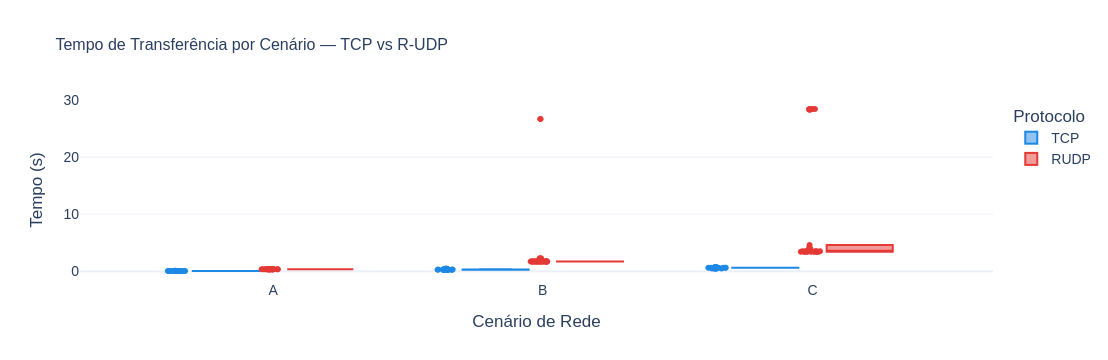

In [5]:
fig1 = px.box(
    cli,
    x='scenario', y='transfer_time_s', color='mode',
    category_orders=SCENARIO_ORDER,
    title='Tempo de Transferência por Cenário — TCP vs R-UDP',
    labels={
        'transfer_time_s': 'Tempo (s)',
        'scenario':        'Cenário de Rede',
        'mode':            'Protocolo',
    },
    color_discrete_map=COLORS,
    points='all',
)
fig1.update_layout(
    template='plotly_white',
    font=dict(size=14),
    title_font_size=16,
    legend_title_text='Protocolo',
)
fig1.show()

## Figura 2 — Throughput Médio por Cenário

Barras de erro representam ±1 desvio padrão. A escala logarítmica opcional (comente/descomente) ajuda a visualizar a diferença entre TCP (dezenas de MB/s) e R-UDP nos cenários B e C (décimos de MB/s).

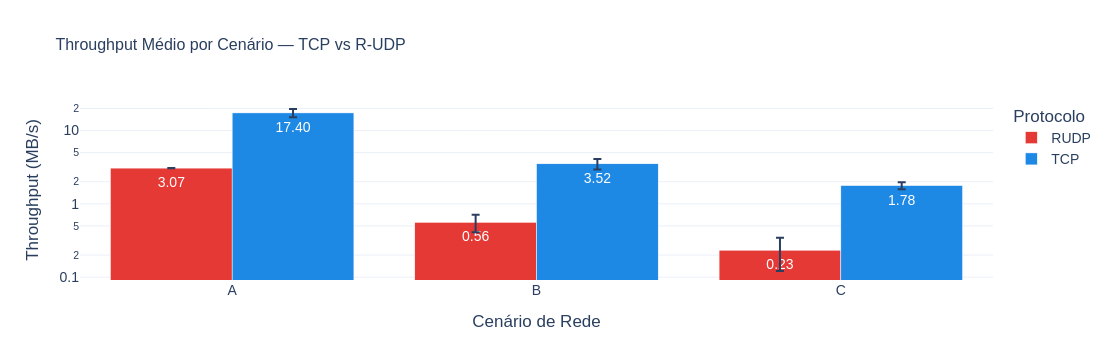

In [8]:
stats_r = stats.reset_index()

fig2 = px.bar(
    stats_r,
    x='scenario', y='mean_tput', color='mode',
    barmode='group',
    error_y='std_tput',
    category_orders=SCENARIO_ORDER,
    title='Throughput Médio por Cenário — TCP vs R-UDP',
    labels={
        'mean_tput': 'Throughput (MB/s)',
        'scenario':  'Cenário de Rede',
        'mode':      'Protocolo',
    },
    color_discrete_map=COLORS,
    text_auto='.2f',
)
fig2.update_layout(
    template='plotly_white',
    font=dict(size=14),
    title_font_size=16,
    legend_title_text='Protocolo',
)
# Descomente para escala logarítmica:
fig2.update_yaxes(type='log')
fig2.show()

## Figura 3 — Retransmissões R-UDP por Cenário

Go-Back-N com janela deslizante de 8 segmentos. O alto desvio padrão nos cenários B e C reflete a natureza estocástica da perda de pacotes: algumas rodadas passam sem retransmissão nenhuma; outras acumulam múltiplos timeouts de 0,5 s.

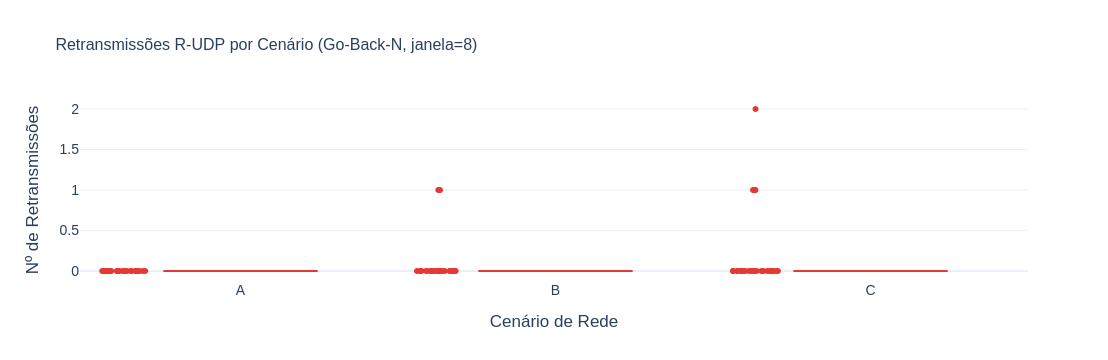

In [9]:
rudp = cli[cli['mode'] == 'RUDP'].copy()

fig3 = px.box(
    rudp,
    x='scenario', y='num_retransmissions',
    category_orders=SCENARIO_ORDER,
    title='Retransmissões R-UDP por Cenário (Go-Back-N, janela=8)',
    labels={
        'num_retransmissions': 'Nº de Retransmissões',
        'scenario':            'Cenário de Rede',
    },
    color_discrete_sequence=[COLORS['RUDP']],
    points='all',
)
fig3.update_layout(
    template='plotly_white',
    font=dict(size=14),
    title_font_size=16,
)
fig3.show()

## Figura 4 — Cross-validação: Tempo Cliente vs Servidor

Cada ponto é uma transferência individual. Pontos próximos à linha `y = x` indicam que cliente e servidor mediram durações equivalentes — validando a consistência dos logs. Desvios expressivos indicariam divergência entre as perspectivas (ex.: transferência parcial não detectada pelo checksum).

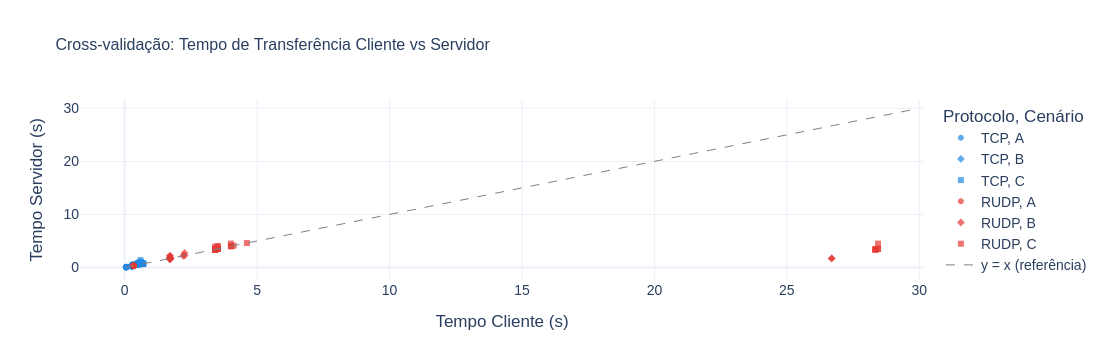

In [10]:
fig4 = px.scatter(
    merged,
    x='transfer_time_s_cli', y='transfer_time_s_srv',
    color='mode_cli', symbol='scenario_cli',
    title='Cross-validação: Tempo de Transferência Cliente vs Servidor',
    labels={
        'transfer_time_s_cli': 'Tempo Cliente (s)',
        'transfer_time_s_srv': 'Tempo Servidor (s)',
        'mode_cli':            'Protocolo',
        'scenario_cli':        'Cenário',
    },
    color_discrete_map=COLORS,
    opacity=0.7,
)
max_val = max(
    merged['transfer_time_s_cli'].max(),
    merged['transfer_time_s_srv'].max(),
) * 1.05
fig4.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val],
    mode='lines',
    line=dict(dash='dash', color='gray', width=1),
    name='y = x (referência)',
))
fig4.update_layout(
    template='plotly_white',
    font=dict(size=14),
    title_font_size=16,
)
fig4.show()

## Prova do X-Custom-Auth no pcap

## Figura 5 — Cross-validação: Métricas de App vs tcpdump

Cada transferência gera dois registros independentes:
- **App metrics** (JSONL): medidos pela aplicação Python via `time.monotonic()`
- **pcap metrics** (tcpdump): timestamps dos pacotes capturados em `/app/logs/pcap/`

**Duração (métrica principal):**
- TCP: `pcap_duration > transfer_time_s` — esperado, pois o pcap inclui o handshake TCP (SYN/SYN-ACK) que ocorre *antes* de `send_file()` ser chamado. O delta ≈ 1 RTT × número de trocas de handshake.
- RUDP: `pcap_duration < transfer_time_s` — esperado, pois `finish()` computa checksum e serializa o log *após* o último pacote ser recebido, enquanto o pcap para quando o cliente encerra.

**Bytes (métrica auxiliar):**
O ambiente Docker com TSO/GRO (*TCP/Generic Segmentation Offload*) faz com que o kernel apresente ao tcpdump "super-segmentos" maiores que o MTU antes da segmentação de hardware. Por isso `pcap_c2s_bytes < bytes_sent`. Esse comportamento não indica perda de dados — os checksums MD5 validam a integridade das transferências.

In [11]:
# ── Carrega pcap_summary e normaliza colunas ──────────────────────────────────
pcap_df = pd.read_csv('logs/csv/pcap_summary.csv')
pcap_df['mode']    = pcap_df['mode'].str.upper()       # tcp→TCP, rudp→RUDP
pcap_df['rep_key'] = pcap_df['rep'].astype(int)

# Atribui rep sequencial dentro de cada (mode, scenario) pelo start_time
cli_sorted = cli.sort_values(['mode', 'scenario', 'start_time']).copy()
cli_sorted['rep_key'] = cli_sorted.groupby(['mode', 'scenario']).cumcount() + 1

# Join por (mode, scenario, rep_key)
xval = cli_sorted.merge(pcap_df, on=['mode', 'scenario', 'rep_key'], how='inner')
print(f'Registros joined: {len(xval)}')

# ── Tabela de cross-validação agregada ───────────────────────────────────────
xval_agg = xval.groupby(['mode', 'scenario']).agg(
    app_mean_s      =('transfer_time_s',  'mean'),
    pcap_mean_s     =('pcap_duration_s',  'mean'),
    app_bytes       =('bytes_sent',       'mean'),
    pcap_bytes      =('pcap_c2s_bytes',   'mean'),
).round(4)
xval_agg['delta_s_pct'] = (
    (xval_agg['pcap_mean_s'] - xval_agg['app_mean_s']) / xval_agg['app_mean_s'] * 100
).round(1)

out = xval_agg[['app_mean_s', 'pcap_mean_s', 'delta_s_pct',
                 'app_bytes', 'pcap_bytes']].copy()
out.columns = ['App (s)', 'pcap (s)', 'Δ (%)', 'App bytes', 'pcap c2s bytes']
display(out)

Registros joined: 180


App (s)  pcap (s)  Δ (%)  App bytes  pcap c2s bytes
mode scenario                                                     
RUDP A          0.3416    0.2994  -12.4  1048576.0     929858.1333
     B          3.4327    3.1888   -7.1  1048576.0     966671.4667
     C          9.3881    8.9159   -5.0  1048576.0     989445.8667
TCP  A          0.0614    0.0915   49.0  1048576.0     931730.4000
     B          0.3074    0.4580   49.0  1048576.0     809025.8667
     C          0.5975    0.9194   53.9  1048576.0     668260.8000

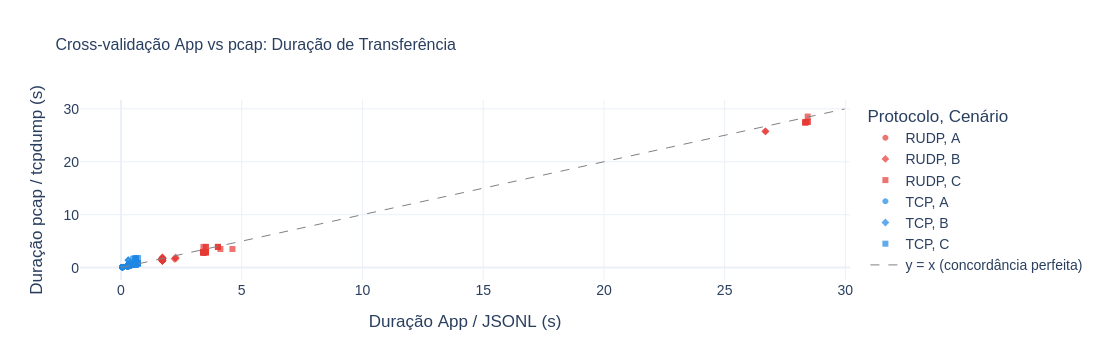

In [12]:
fig5 = px.scatter(
    xval,
    x='transfer_time_s', y='pcap_duration_s',
    color='mode', symbol='scenario',
    title='Cross-validação App vs pcap: Duração de Transferência',
    labels={
        'transfer_time_s':  'Duração App / JSONL (s)',
        'pcap_duration_s':  'Duração pcap / tcpdump (s)',
        'mode':             'Protocolo',
        'scenario':         'Cenário',
    },
    color_discrete_map=COLORS,
    opacity=0.7,
)
max_val = max(xval['transfer_time_s'].max(), xval['pcap_duration_s'].max()) * 1.05
fig5.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val],
    mode='lines',
    line=dict(dash='dash', color='gray', width=1),
    name='y = x (concordância perfeita)',
))
fig5.update_layout(
    template='plotly_white',
    font=dict(size=14),
    title_font_size=16,
)
fig5.show()

In [13]:
import subprocess

# Verifica presença do X-Custom-Auth em um pcap TCP e um RUDP
for mode, sc, rep in [('tcp', 'A', '01'), ('rudp', 'A', '01')]:
    pcap = f'/app/logs/pcap/capture_{mode}_{sc}_{rep}.pcap'
    result = subprocess.run(
        ['docker', 'exec', 'ft-server', 'tcpdump', '-r', pcap, '-A'],
        capture_output=True, text=True
    )
    found = 'ANTHONY' in result.stdout
    line  = next((l.strip() for l in result.stdout.splitlines() if 'ANTHONY' in l), '')
    print(f'capture_{mode}_{sc}_{rep}.pcap → X-Custom-Auth encontrado: {found}')
    if line:
        print(f'  └─ {line[:80]}')

capture_tcp_A_01.pcap → X-Custom-Auth encontrado: True
  └─ .+b...m.RDFT............."Ie......	$..20261011410 ANTHONY IRLAN MARQUES LUZ.....
capture_rudp_A_01.pcap → X-Custom-Auth encontrado: True
  └─ ..MN.^)....d..20261011410 ANTHONY IRLAN MARQUES LUZ.............................
